# Phase mixing con autogravedad: qué es la meseta de $h_1$

Todo lo anterior se hizo con el fondo isócrono fijo, donde $J$ es una constante
exacta del movimiento y existe una respuesta cerrada contra la que comparar. Aquí
se activa la gravedad de las propias partículas.

**La configuración.** La distribución gaussiana,
$F_0 \propto e^{-\sin^2(Q/2)/\sigma_Q^2}\,e^{-J^2/\sigma_J^2} J^2$, con masa total
$a_0 = 10^{-3}$, **una milésima de la masa del isócrono**. $N = 10^4$ partículas,
yoshida4 con $\Delta t = 0.1$, hasta $t = 2000$ (unos 20 periodos orbitales), con
cuadratura y con Monte Carlo, y un **control sin autogravedad** con todo lo demás
idéntico.

**Resumen de lo que se establece abajo.**

1. La energía se conserva a $1.7\times10^{-7}$. El $5\times10^{-4}$ que reportaban
   las corridas viejas era un bug del diagnóstico (faltaba el $\tfrac12$ de la
   autoenergía), corregido en `b0f3915`.
2. El decaimiento es phase mixing (envolvente gaussiana), acelerado un 2.5% por la
   autogravedad.
3. $|h_1|$ se detiene en una meseta de $1.77\times10^{-3}h_0$ que ninguna
   discretización mueve y que escala con $a_0$.
4. La meseta no es un modo: su fase está congelada. Es el efecto de calcular $(Q,J)$
   con el mapa del isócrono cuando el potencial ya no es el isócrono: **con el mapa
   ángulo-acción del potencial real desaparece** (sección 7).
5. Queda una componente pequeña que gira a frecuencia orbital: física hasta
   $t=2000$ y ruido de discreción después, también con $a_0=10^{-2}$ donde crece
   (sección 8).
   Las preguntas abiertas están en `PREGUNTAS_ABIERTAS.md`.

Los mismos resultados, con más contexto, están en `docs/introduccion/vlasov_intro.tex`.

In [1]:
import os, sys, numpy as np, h5py
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.dpi':120,'font.size':9,'axes.grid':True,'grid.alpha':.25})

DATA = '../../exe/sg'
assert os.path.isdir(DATA), os.path.abspath(DATA)
sys.path.insert(0, '../scripts')
from df0 import rp_to_QJ, omega

def leer(d):
    a = np.loadtxt(os.path.join(DATA, d, 'hk1_complex.tl'))
    return a[:,0], np.array([a[:,1+2*k] + 1j*a[:,2+2*k] for k in range(5)])

def meseta(d, a=1600, b=2000):
    t, h = leer(d)
    m = (t >= a) & (t <= b)
    return np.median(np.abs(h[1][m]))/h[0].real[0]

RUNS = {'sin autogravedad':'quad_nosg', 'autogravedad, cuadratura':'quad',
        'autogravedad, Monte Carlo':'mc'}
COL = {'sin autogravedad':'k', 'autogravedad, cuadratura':'tab:blue',
       'autogravedad, Monte Carlo':'tab:red'}
T, H = {}, {}
for k, d in RUNS.items():
    T[k], H[k] = leer(d)
c = 0.5*(2 + np.sqrt(8)); Jp = 0.1
print(f'omega(J=0.1) = {omega(Jp):.5f}   periodo = {2*np.pi/omega(Jp):.1f}')

omega(J=0.1) = 0.06292   periodo = 99.9


/home/erik/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Salud numérica: energía y $h_0$

**El bug.** `energy.f90` sumaba $\sum_j f_j(\tfrac12p_j^2+\Phi_{\rm total}(r_j))$. Con
autogravedad eso no es la energía: la energía de interacción es
$\tfrac12\sum_j f_j\Phi_{\rm self}(r_j)$, porque al sumar el potencial propio sobre
todas las partículas cada par se cuenta desde ambos lados. La suma incorrecta
cambia en $\tfrac12\Delta W_{\rm self}$ cuando el phase mixing redistribuye la masa.

Se delató porque el error no se movía con ninguna discretización y escalaba con
$a_0$. Las corridas `efix_*` son las mismas que `quad` y `quad_nosg`, repetidas con
el código corregido: trayectorias idénticas bit a bit, energía distinta.

In [2]:
def energia(d):
    f = h5py.File(os.path.join(DATA, d, 'vlasov_output.h5'))
    st = sorted([s for s in f if s.startswith('step_')], key=lambda s:int(s.split('_')[1]))
    return f[st[-1]].attrs['total_energy']/f[st[0]].attrs['total_energy'] - 1

print(f"{'':>28} {'antes del arreglo':>18} {'con el arreglo':>15}")
print(f"{'dE/E con autogravedad':>28} {energia('quad'):>+18.4e} {energia('efix_quad'):>+15.4e}")
print(f"{'dE/E sin autogravedad':>28} {energia('quad_nosg'):>+18.4e} {energia('efix_nosg'):>+15.4e}")
fo = h5py.File(os.path.join(DATA, 'quad', 'vlasov_output.h5'))
fn = h5py.File(os.path.join(DATA, 'efix_quad', 'vlasov_output.h5'))
s = sorted([s for s in fo if s.startswith('step_')])[-1]
print('\nposiciones a t=2000 idénticas bit a bit:',
      np.array_equal(fo[s]['r_part'][:], fn[s]['r_part'][:]) and
      np.array_equal(fo[s]['p_part'][:], fn[s]['p_part'][:]))

                              antes del arreglo  con el arreglo
       dE/E con autogravedad        -4.9595e-04     -1.6975e-07
       dE/E sin autogravedad        +7.0056e-11     +7.0058e-11

posiciones a t=2000 idénticas bit a bit: True


                   corrida   cambio de h_0
          sin autogravedad     -2.4433e-10
  autogravedad, cuadratura     -1.6019e-02
 autogravedad, Monte Carlo     -1.6018e-02


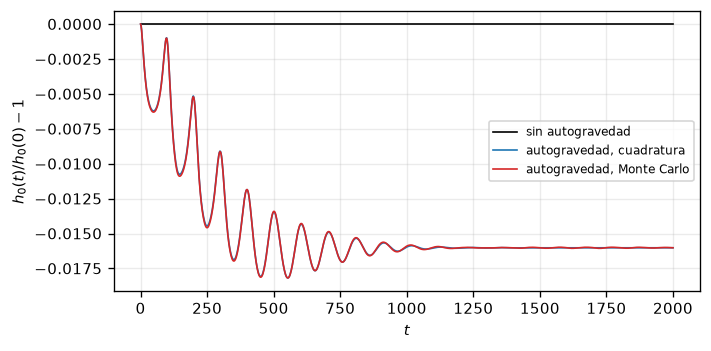

In [3]:
print(f"{'corrida':>26} {'cambio de h_0':>15}")
for k, d in RUNS.items():
    h0 = H[k][0].real
    print(f'{k:>26} {h0[-1]/h0[0]-1:>+15.4e}')
fig, ax = plt.subplots(figsize=(6, 3))
for k in RUNS:
    ax.plot(T[k], H[k][0].real/H[k][0].real[0]-1, color=COL[k], lw=1, label=k)
ax.set_xlabel('$t$'); ax.set_ylabel('$h_0(t)/h_0(0)-1$'); ax.legend(fontsize=7)
fig.tight_layout()

**$h_0$ cambia un $1.6\%$**, igual a cuatro cifras en los dos esquemas de muestreo, y
sin autogravedad se conserva a $2\times10^{-10}$. No es ruido: $h_0$ mide
$\langle B(J_{\rm iso})\rangle$, y la acción *isócrona* deja de conservarse cuando el
potencial ya no es el isócrono. El cambio ocurre durante la mezcla inicial
($t\lesssim600$) y después $h_0$ queda constante: no es una deriva secular.

## 2. ¿Phase mixing o Landau damping? La forma de la envolvente

- **Phase mixing:** $|h_k|\propto \exp[-(k\,|\omega'|\,\sigma\,t)^2/4]$, recta frente a $t^2$.
- **Landau damping:** $|h_k|\propto e^{-\gamma t}$, recta frente a $t$.

                   corrida  R^2 vs t^2  R^2 vs t  pendiente vs t^2
          sin autogravedad     1.00000     0.938       -3.7262e-06
  autogravedad, cuadratura     0.99861     0.938       -3.8200e-06
 autogravedad, Monte Carlo     0.99859     0.938       -3.8434e-06
   autogravedad, cuadratura: decae +2.5% más rápido que sin autogravedad
   autogravedad, Monte Carlo: decae +3.1% más rápido que sin autogravedad


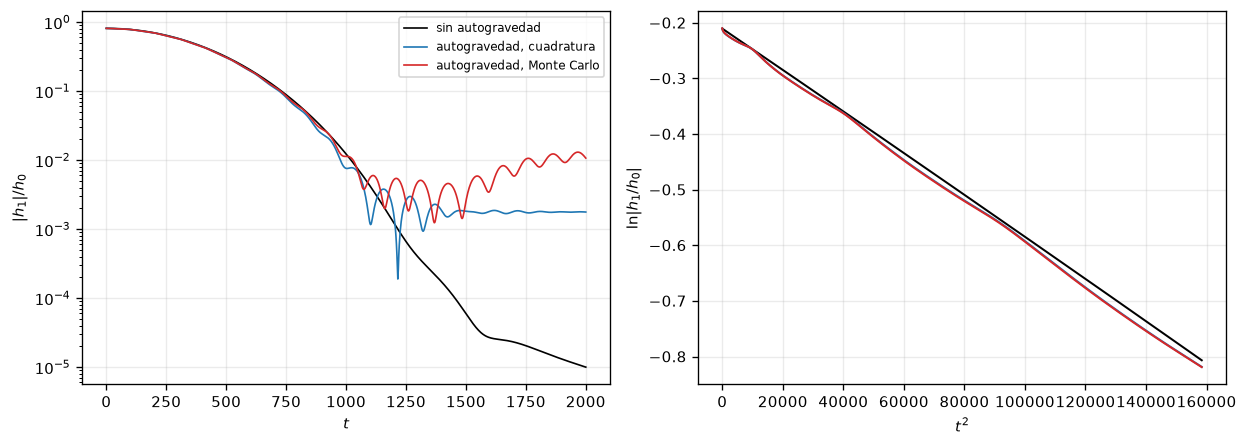

In [4]:
print(f"{'corrida':>26} {'R^2 vs t^2':>11} {'R^2 vs t':>9} {'pendiente vs t^2':>17}")
coef = {}
for k in RUNS:
    t, h = T[k], np.abs(H[k][1])
    m = (t > 0) & (t < 250)
    y = np.log(h[m])
    coef[k] = np.polyfit(t[m]**2, y, 1)[0]
    print(f'{k:>26} {np.corrcoef(t[m]**2, y)[0,1]**2:>11.5f} '
          f'{np.corrcoef(t[m], y)[0,1]**2:>9.3f} {coef[k]:>17.4e}')
b0 = coef['sin autogravedad']
for k in list(RUNS)[1:]:
    print(f'   {k}: decae {coef[k]/b0-1:+.1%} más rápido que sin autogravedad')

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
for k in RUNS:
    t, h = T[k], np.abs(H[k][1])/H[k][0].real[0]
    axes[0].semilogy(t, h, lw=1, color=COL[k], label=k)
    m = t < 400
    axes[1].plot(t[m]**2, np.log(h[m]), lw=1.2, color=COL[k])
axes[0].set_xlabel('$t$'); axes[0].set_ylabel('$|h_1|/h_0$'); axes[0].legend(fontsize=7)
axes[1].set_xlabel('$t^2$'); axes[1].set_ylabel(r'$\ln|h_1/h_0|$')
fig.tight_layout()

Gaussiana en las tres ($R^2 = 1.00000$ sin autogravedad, $0.9986$ con ella, frente a
$0.938$ para la exponencial). La autogravedad acelera el decaimiento un 2.5–3%,
coherentemente en los dos esquemas: es lo que queda del efecto colectivo con
$a_0=10^{-3}$.

Pero con autogravedad $|h_1|$ **deja de decaer** y queda en una meseta.

## 3. La meseta frente a la discretización y a la masa

Si fuera ruido de discretización, cambiaría al refinar. Si es física, no cambia y
escala con $a_0$.

In [5]:
BARRIDOS = [
    ('malla dr',      [('0.2','scan_dr_0.200'), ('0.1','quad'), ('0.05','scan_dr_0.050'), ('0.025','scan_dr_0.025')]),
    ('orden B-spline',[('1','quad'), ('2','scan_bspl_2'), ('3','scan_bspl_3')]),
    ('nodos en Q',    [('25','quad'), ('100','scan_npc_100'), ('200','scan_npc_200')]),
    ('partículas N',  [('1e3','scan_N_1000'), ('1e4','quad'), ('1e5','scan_N_100000')]),
]
for nombre, runs in BARRIDOS:
    print(f'{nombre:>15}: ' + '   '.join(f'{lab}: {meseta(d):.4e}' for lab, d in runs))

def estatica(d, a, b):
    t, h = leer(d)
    m = (t >= a) & (t <= b)
    return abs((h[1][m]/h[0].real[0]).mean())

print('\nmasa, corridas hasta t=20000 (parte estática = promedio complejo; la mediana de')
print('|h_1| la infla con a0=1e-2 una componente que gira, ruido de discreción, sección 8):')
A = [1e-4, 1e-3, 1e-2]
for a, b in [(1600, 2000), (15000, 20000)]:
    nombres = [f'long_a0_{x:.0e}'.replace('e-0', 'e-') for x in A]
    S = [estatica(d, a, b) for d in nombres]
    M = [meseta(d, a, b) for d in nombres]
    print(f'   t in [{a},{b}]: parte estática ' + '  '.join(f'{m:.4e}' for m in S)
          + f'  pendiente {np.polyfit(np.log(A), np.log(S), 1)[0]:+.3f}'
          + f'   | mediana de |h1| ' + '  '.join(f'{m:.4e}' for m in M)
          + f'  pendiente {np.polyfit(np.log(A), np.log(M), 1)[0]:+.3f}')

       malla dr: 0.2: 1.7708e-03   0.1: 1.7698e-03   0.05: 1.7701e-03   0.025: 1.7706e-03
 orden B-spline: 1: 1.7698e-03   2: 1.7697e-03   3: 1.7695e-03
     nodos en Q: 25: 1.7698e-03   100: 1.7698e-03   200: 1.7680e-03
   partículas N: 1e3: 1.7626e-03   1e4: 1.7698e-03   1e5: 1.7696e-03

masa, corridas hasta t=20000 (parte estática = promedio complejo; la mediana de
|h_1| la infla con a0=1e-2 una componente que gira, ruido de discreción, sección 8):
   t in [1600,2000]: parte estática 1.8431e-04  1.7702e-03  1.2289e-02  pendiente +0.912   | mediana de |h1| 1.8644e-04  1.7698e-03  1.2306e-02  pendiente +0.910
   t in [15000,20000]: parte estática 1.8356e-04  1.7669e-03  1.2383e-02  pendiente +0.915   | mediana de |h1| 1.8356e-04  1.7713e-03  1.5609e-02  pendiente +0.965


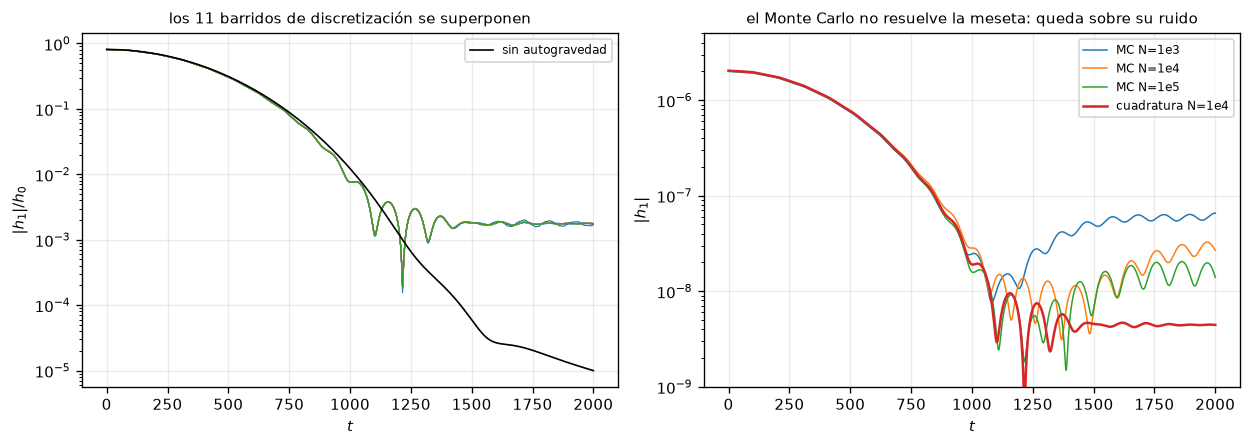

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
for nombre, runs in BARRIDOS:
    for lab, d in runs:
        t, h = leer(d)
        axes[0].semilogy(t, np.abs(h[1])/h[0].real[0], lw=.7)
t, h = leer('quad_nosg')
axes[0].semilogy(t, np.abs(h[1])/h[0].real[0], 'k-', lw=1, label='sin autogravedad')
axes[0].set_title('los 11 barridos de discretización se superponen', fontsize=9)
axes[0].set_xlabel('$t$'); axes[0].set_ylabel('$|h_1|/h_0$'); axes[0].legend(fontsize=7)
for d, lab in [('mc_1000','MC N=1e3'), ('mc','MC N=1e4'), ('mc_100000','MC N=1e5'), ('quad','cuadratura N=1e4')]:
    t, h = leer(d)
    axes[1].semilogy(t, np.abs(h[1]), lw=.9 if d.startswith('mc') else 1.5, label=lab)
axes[1].set_ylim(1e-9, 5e-6); axes[1].set_xlabel('$t$'); axes[1].set_ylabel('$|h_1|$')
axes[1].set_title('el Monte Carlo no resuelve la meseta: queda sobre su ruido', fontsize=9)
axes[1].legend(fontsize=7)
fig.tight_layout()

**Nada de la discretización la mueve** (todos los valores entre $1.763$ y
$1.771\times10^{-3}$ con ocho veces más malla, splines cúbicos, ocho veces más nodos
angulares o cien veces más partículas) y **escala con la masa**: la parte estática
tiene pendiente $+0.91$ en las dos ventanas. La mediana de $|h_1|$ da $+0.96$ en la
ventana tardía, pero solo porque con $a_0=10^{-2}$ la infla la componente que gira.

El Monte Carlo no sirve aquí: el nivel de la meseta ($4.4\times10^{-9}$) queda por
debajo de su ruido en todo el rango de $N$ explorado. La primera versión de este
análisis concluyó por eso que la meseta era ruido; era un error.

## 4. No es un modo: la fase

Un modo oscila, $h_1\sim e^{-i\omega_r t}$. Se descompone $h_1 = S + R(t)$ en una
parte estática $S$ (el promedio temporal) y una que fluctúa.

    a0        ventana  omega efectiva      |S|/h0   arg S  gira/|S|  a omega
0.0001   [2000,15000]        +8.3e-09  1.8357e-04  -0.000      1.4%   0.0614
0.0001  [15000,20000]        +8.5e-08  1.8356e-04  +0.000      1.3%   0.0578
 0.001   [2000,15000]        +3.5e-10  1.7669e-03  +0.000      8.7%   0.0575
 0.001  [15000,20000]        +1.7e-07  1.7669e-03  -0.000     10.2%   0.0590
  0.01   [2000,15000]        +1.8e-07  1.2330e-02  -0.001     18.1%   0.0624
  0.01  [15000,20000]        +1.4e-02  1.2383e-02  +0.001     85.9%   0.0616


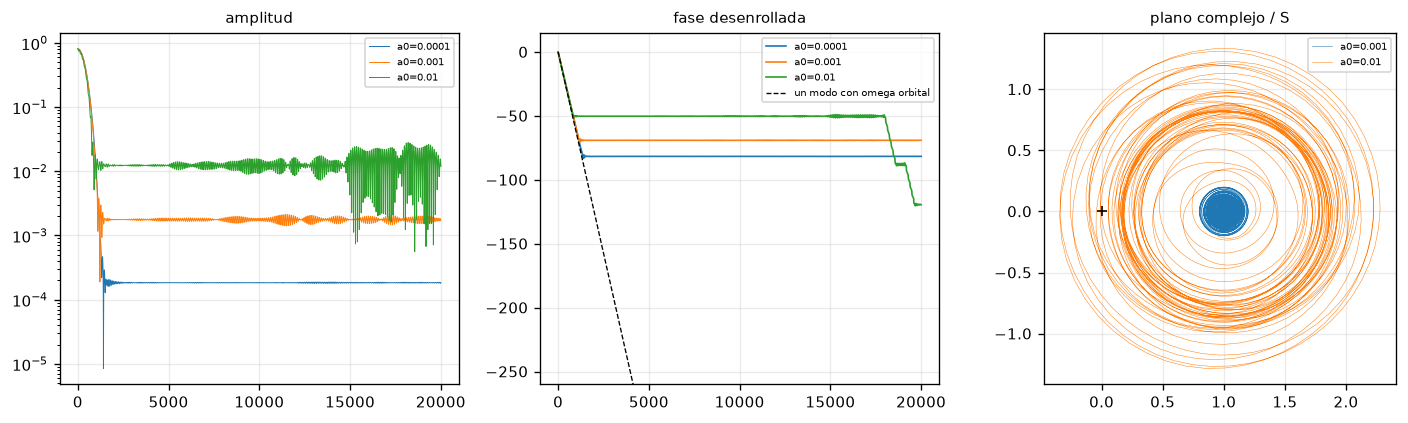

In [7]:
print(f"{'a0':>6} {'ventana':>14} {'omega efectiva':>15} {'|S|/h0':>11} {'arg S':>7} {'gira/|S|':>9} {'a omega':>8}")
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
for a0 in A:
    d = f'long_a0_{a0:.0e}'.replace('e-0', 'e-')
    t, h = leer(d); z = h[1]/h[0].real[0]
    fase = np.unwrap(np.angle(z))
    axes[0].semilogy(t, np.abs(z), lw=.6, label=f'a0={a0:g}')
    axes[1].plot(t, fase, lw=1, label=f'a0={a0:g}')
    for a, b in [(2000, 15000), (15000, 20000)]:
        m = (t >= a) & (t <= b)
        S = z[m].mean(); giro = np.sqrt(2)*np.std(z[m].real)
        sp = np.abs(np.fft.rfft(z[m].real - z[m].real.mean()))
        wp = (np.fft.rfftfreq(m.sum(), t[1]-t[0])*2*np.pi)[np.argmax(sp)]
        print(f'{a0:>6g} {f"[{a},{b}]":>14} {-np.polyfit(t[m], fase[m], 1)[0]:>+15.1e} '
              f'{abs(S):>11.4e} {np.angle(S):>+7.3f} {giro/abs(S):>9.1%} {wp:>8.4f}')
    if a0 >= 1e-3:
        S0 = abs(z[(t >= 2000) & (t <= 15000)].mean())
        m = t >= (2000 if a0 == 1e-3 else 15000)
        axes[2].plot(z[m].real/S0, z[m].imag/S0, lw=.3, label=f'a0={a0:g}')
axes[1].plot(t, -omega(0.1)*t, 'k--', lw=.8, label='un modo con omega orbital')
axes[1].set_ylim(-260, 15)
axes[2].plot(0, 0, 'k+'); axes[2].set_aspect('equal')
for ax, tt in zip(axes, ['amplitud', 'fase desenrollada', 'plano complejo / S']):
    ax.set_title(tt, fontsize=9); ax.legend(fontsize=6)
fig.tight_layout()

Con $a_0=10^{-3}$ la parte estática es **real con fase 0.000** y su módulo es el mismo
en las dos ventanas; la fase total recorre menos de 0.4 rad entre $t=2000$ y $15\,000$,
cuando un modo a frecuencia orbital habría acumulado más de $10^3$. **No es un modo.**

Queda una componente que gira a $\omega\approx0.055$–$0.062$, dentro de la banda
orbital: $1.4\%$ de $S$ con $a_0=10^{-4}$, $9$–$10\%$ con $10^{-3}$, y con $10^{-2}$
crece de $18\%$ a $86\%$ hasta rodear el origen, lo que produce los saltos de fase.

## 5. La explicación: las coordenadas

El diagnóstico calcula $(Q,J)$ con el mapa del isócrono, pero las partículas se mueven
en $\Phi_{\rm iso}+\delta\Phi$. Una distribución completamente mezclada en las
variables verdaderas no sale uniforme en $Q_{\rm iso}$: escribiendo
$J_{\rm iso}=J+\delta J(\theta)$ y $Q_{\rm iso}=\theta+\delta Q(\theta)$, con
correcciones de orden $a_0$, el promedio de $e^{-iQ_{\rm iso}}B(J_{\rm iso})$ sobre
$\theta$ uniforme conserva la componente $k=1$ de $\delta J$ y $\delta Q$: un término
constante, proporcional a $a_0$.

**Predicción:** la $J$ isócrona de cada partícula debe oscilar a su frecuencia orbital.

<J>=0.3000: pico a pico 0.45%  deriva +0.003%  omega oscilación 0.0502  orbital 0.0500
<J>=0.4482: pico a pico 0.44%  deriva -0.002%  omega oscilación 0.0439  orbital 0.0426
<J>=0.5914: pico a pico 0.45%  deriva -0.026%  omega oscilación 0.0376  orbital 0.0368


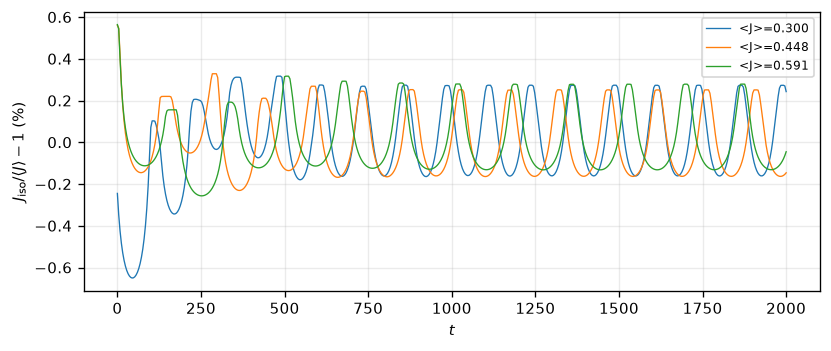

In [8]:
f = h5py.File(os.path.join(DATA, 'long_fino', 'vlasov_output.h5'))
st = sorted([s for s in f if s.startswith('step_')], key=lambda s:int(s.split('_')[1]))
t = np.array([f[s].attrs['time'] for s in st])
idx = [4978, 7500, 9900]
R = np.array([f[s]['r_part'][idx] for s in st]); P = np.array([f[s]['p_part'][idx] for s in st])
_, J = rp_to_QJ(R, P)
fig, ax = plt.subplots(figsize=(7, 3))
m = t > 500
for i in range(3):
    x = J[:, i]; Jm = x.mean()
    sp = np.abs(np.fft.rfft(x - Jm)); fr = np.fft.rfftfreq(len(x), t[1]-t[0])*2*np.pi
    d1 = x[(t > 500) & (t <= 1250)].mean(); d2 = x[t > 1250].mean()
    print(f'<J>={Jm:.4f}: pico a pico {100*np.ptp(x[m])/Jm:.2f}%  deriva {100*(d2-d1)/Jm:+.3f}%  '
          f'omega oscilación {fr[np.argmax(sp)]:.4f}  orbital {omega(Jm):.4f}')
    ax.plot(t, 100*(x/Jm - 1), lw=.8, label=f'<J>={Jm:.3f}')
ax.set_xlabel('$t$'); ax.set_ylabel(r'$J_{\rm iso}/\langle J\rangle-1$ (%)'); ax.legend(fontsize=7)
fig.tight_layout()

**Confirmado en partículas individuales:** $J_{\rm iso}$ oscila $\sim0.45\%$ pico a
pico exactamente a la frecuencia orbital, sin deriva apreciable de la media.

## 6. Análisis por filas de acción

Con cuadratura, cada fila de la rejilla tiene una sola acción inicial y, bajo phase
mixing puro, rota rígida: su contribución $g_i(t)$ a $h_1$ no decae. Se ajusta
$g_i(t)=S_i+A_i e^{-i\omega_i t}$ en $t\in[600,2000]$ para separar la parte estática
de cada fila de su propia rotación (`reproducir/scripts/filas_J.py`).

In [9]:
import filas_J
_ = filas_J.analizar('long_fino_nosg')
_ = filas_J.analizar('long_fino')


=== long_fino_nosg: 400 filas, 501 instantáneas
  h_1 del código / suma por filas: 1.688514e-02  (dispersión relativa 2.5e-14, fase 1.8e-13)
  1. corrimiento de frecuencia de las filas, omega_medida - omega_iso(J0):
     J0=0.050: omega_iso=0.06681  dw=-1.76e-11  (dw/omega=-2.6e-10)   <J_iso>-J0=+4.02e-16
     J0=0.100: omega_iso=0.06294  dw=-1.90e-11  (dw/omega=-3.0e-10)   <J_iso>-J0=+1.26e-15
     J0=0.149: omega_iso=0.05936  dw=-1.68e-11  (dw/omega=-2.8e-10)   <J_iso>-J0=+2.33e-15
     J0=0.200: omega_iso=0.05596  dw=-1.06e-11  (dw/omega=-1.9e-10)   <J_iso>-J0=-1.94e-15
     J0=0.299: omega_iso=0.05005  dw=+1.10e-11  (dw/omega=+2.2e-10)   <J_iso>-J0=-7.54e-14
     J0=0.400: omega_iso=0.04488  dw=+4.26e-11  (dw/omega=+9.5e-10)   <J_iso>-J0=-9.12e-13
     |g_i| tardío / inicial, filas con peso: mediana 1.0000  rango [1.0000, 1.0000]
  2. ajuste por fila: residuo relativo mediano 4.8e-10, máximo 7.0e-09
     parte estática total |sum S_i|/h0 = 4.866e-10, arg = +0.001
     sum|S_i| / |

- **Sin autogravedad**, cada fila rota rígida a $\omega_{\rm iso}(J)$ (corrimiento
  $\sim10^{-11}$), sin parte estática ni cambio de amplitud: el control funciona.
- **Con autogravedad**, cada fila lleva una parte estática pequeña ($0.2$–$2\%$ de su
  amplitud) y **todas en fase** ($\sum|S_i|/|\sum S_i|\approx1.2$), concentradas donde
  pesa la función de prueba. Es lo que predice la explicación por coordenadas.
- Hasta $t=2000$, la componente que gira del total es el continuo de filas que todavía
  no termina de cancelarse; los residuos del ajuste están en la propia $\omega_i$ y en
  $2\omega_i$ de cada fila y son **incoherentes entre filas**: no hay un modo con
  frecuencia común.
- Pero ese continuo, extrapolado, bajaría a $\sim0.1\%$ de $S$ hacia $t=20\,000$,
  mientras que la medida es $\sim10\%$. Para ver por qué, se repitió la corrida hasta
  $t=20\,000$ con instantáneas y se ajustó por ventanas.

In [10]:
_ = filas_J.por_ventanas('long20k_snap')


=== long20k_snap: ventanas de 2000
         ventana     |S|/h0   arg S  rms(h-S)/|S|  rms C/|S|  rms res/|S|  sum|S_i|/|S|  <|A|/|g0|>   dw medio
      [600,2600] 1.8200e-03  +0.017        24.452     23.704        0.854          1.18      0.9608  +7.57e-05
     [2600,4600] 1.7663e-03  +0.000         0.032      0.036        0.009          1.19      0.9114  +7.56e-05
     [4600,6600] 1.7665e-03  +0.001         0.056      0.054        0.022          1.20      0.8447  +7.56e-05
     [6600,8600] 1.7666e-03  +0.000         0.064      0.061        0.010          1.21      0.7656  +7.53e-05
    [8600,10600] 1.7659e-03  -0.000         0.083      0.074        0.017          1.21      0.6768  +7.47e-05
   [10600,12600] 1.7666e-03  +0.000         0.142      0.147        0.025          1.22      0.5811  +7.38e-05
   [12600,14600] 1.7661e-03  +0.000         0.116      0.115        0.037          1.22      0.4797  +7.12e-05
   [14600,16600] 1.7657e-03  -0.001         0.086      0.092        0.025   

- **La parte estática no cambia** en 16\,000 unidades de tiempo (cuarta cifra).
- **La componente que gira es, ventana por ventana, el continuo de filas**
  (rms $C$ = rms $(h-S)$; residuos 3–10 veces menores): no hay oscilación coherente.
- **Las filas no son rígidas**: su amplitud cae de 0.91 a 0.26 porque sus partículas
  comparten $J$ isócrona pero no $J$ verdadera, y se desfasan entre sí. Por eso la
  extrapolación desde $t\le2000$ fallaba.

Por qué ese continuo no se cancela por debajo de $\sim10\%$ de $S$ sigue abierto; las
hipótesis y las pruebas propuestas están en `PREGUNTAS_ABIERTAS.md`.

## 7. La prueba directa: el mapa ángulo-acción del potencial real

Si la parte estática es un efecto de coordenadas, al recalcular $h_1$ con las variables
ángulo-acción del potencial **real** (isócrono + potencial propio) debe desaparecer.
El mapa numérico está en `reproducir/scripts/aa_numerico.py` (cuadraturas con la
sustitución $r=r_m+r_a\sin\theta$ y Gauss-Legendre); el cálculo sobre las 501
instantáneas de `long20k_snap`, en `aa_meseta.py`, que guarda `aa_meseta.npz`.

validación: max|dJ| = 1.2e-15, mediana|dQ| = 1.6e-12, max|dQ| = 1.4e-06

     mapa |<h1>|/h0, t in [2000,15000]  rms parte que gira
      iso                    1.767e-03           1.540e-04
 promedio                    7.888e-07           1.541e-04
 instante                    1.443e-06           1.539e-04

correlación de la parte que gira entre los dos mapas: 0.99988


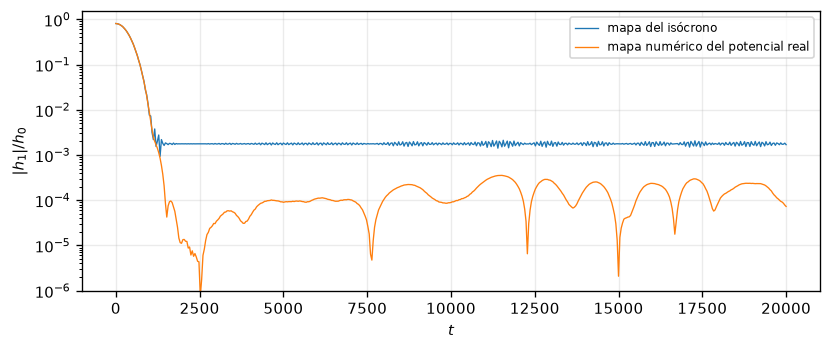

In [11]:
from aa_numerico import MapaAA, phi_iso
# Validación: sin potencial propio, el mapa numérico reproduce el analítico.
f = h5py.File(os.path.join(DATA, 'long_fino_nosg', 'vlasov_output.h5'))
s = sorted([k for k in f if k.startswith('step_')])[250]
r, p = f[s]['r_part'][:], f[s]['p_part'][:]
Qa, Ja = rp_to_QJ(r, p); Qn, Jn, _ = MapaAA()(r, p)
dQ = np.abs(np.angle(np.exp(1j*(Qn - Qa))))
print(f'validación: max|dJ| = {np.max(np.abs(Jn-Ja)):.1e}, mediana|dQ| = {np.median(dQ):.1e}, max|dQ| = {dQ.max():.1e}')

d = np.load(os.path.join(DATA, 'long20k_snap', 'aa_meseta.npz'))
t = d['t']
rms = lambda x: np.sqrt(np.mean(np.abs(x)**2))
print(f"\n{'mapa':>9} {'|<h1>|/h0, t in [2000,15000]':>28} {'rms parte que gira':>19}")
for k in ('iso', 'promedio', 'instante'):
    v = (t >= 2000) & (t <= 15000); z = d[f'h1_{k}'][v]
    print(f'{k:>9} {abs(z.mean()):>28.3e} {rms(z - z.mean()):>19.3e}')
v = t >= 2000
Ri = d['h1_iso'][v] - d['h1_iso'][v].mean(); Rn = d['h1_promedio'][v] - d['h1_promedio'][v].mean()
print(f'\ncorrelación de la parte que gira entre los dos mapas: '
      f'{abs(np.vdot(Ri, Rn))/np.linalg.norm(Ri)/np.linalg.norm(Rn):.5f}')
fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogy(t, np.abs(d['h1_iso']), lw=.8, label='mapa del isócrono')
ax.semilogy(t, np.abs(d['h1_promedio']), lw=.8, label='mapa numérico del potencial real')
ax.set_ylim(1e-6, 1.5); ax.set_xlabel('$t$'); ax.set_ylabel('$|h_1|/h_0$'); ax.legend(fontsize=7)
fig.tight_layout()

**La parte estática desaparece**: baja de $1.77\times10^{-3}$ a $\sim8\times10^{-7}$, unas
2200 veces. La explicación por coordenadas queda confirmada.

**La parte que gira no cambia** (correlación 0.9999 entre los dos mapas): no es un
efecto de coordenadas. Es lo que queda por explicar; ver `PREGUNTAS_ABIERTAS.md`.

## 8. La componente que gira: ¿física o discreción?

No cambia con el mapa, así que no es un efecto de coordenadas. La prueba es cambiar la
resolución: corridas hasta $t=20\,000$ con el doble de filas en $J$ (`long20k_nrc800`)
y con el doble de nodos en $Q$ (`long20k_npc50`), y el control sin autogravedad.

In [12]:
import subprocess
print(subprocess.run([sys.executable, '../scripts/giro_resolucion.py'],
                     capture_output=True, text=True).stdout)

                   corrida         ventana        |S|   rms giro  giro/giro(N=1e4) corr. con N=1e4
   Nrc=400, Npc=25 (N=1e4)     [1600,2000]  1.770e-03  5.675e-05             1.000           1.000
   Nrc=400, Npc=25 (N=1e4)     [2000,6000]  1.767e-03  6.904e-05             1.000           1.000
   Nrc=400, Npc=25 (N=1e4)    [6000,12000]  1.767e-03  1.783e-04             1.000           1.000
   Nrc=400, Npc=25 (N=1e4)   [12000,20000]  1.767e-03  1.804e-04             1.000           1.000
   Nrc=400, Npc=25 (N=1e4)   [15000,20000]  1.767e-03  1.804e-04             1.000           1.000
   Nrc=800, Npc=25 (N=2e4)     [1600,2000]  1.770e-03  5.681e-05             1.001           1.000
   Nrc=800, Npc=25 (N=2e4)     [2000,6000]  1.767e-03  2.108e-05             0.305           0.756
   Nrc=800, Npc=25 (N=2e4)    [6000,12000]  1.767e-03  9.507e-05             0.533           0.838
   Nrc=800, Npc=25 (N=2e4)   [12000,20000]  1.767e-03  1.045e-04             0.579           0.257
   Nrc=800

- **Hasta $t=2000$** es idéntica con cualquier resolución: el continuo, física.
- **Después** baja a 0.3–0.65× al duplicar partículas en $J$ o en $Q$ y deja de estar
  correlacionada con la corrida base: **es ruido de discreción**. Sin autogravedad la
  misma cuadratura cancela hasta $10^{-10}$. Causa plausible, no demostrada: la autogravedad
  desordena la rejilla en acción verdadera y deja un piso de $\sim10^{-4}h_0$.
- La parte estática ($1.767\times10^{-3}$) no depende de la resolución.

Con $a_0=10^{-2}$, donde la componente crece, la misma prueba:

In [13]:
print(subprocess.run([sys.executable, '../scripts/giro_resolucion.py',
                      'long_a0_1e-2', 'long20k_a0_1e-2_nrc800'],
                     capture_output=True, text=True).stdout)

                   corrida         ventana        |S|   rms giro  giro/giro(N=1e4) corr. con N=1e4
              long_a0_1e-2     [1600,2000]  1.229e-02  4.738e-04             1.000           1.000
              long_a0_1e-2     [2000,6000]  1.234e-02  7.560e-04             1.000           1.000
              long_a0_1e-2    [6000,12000]  1.233e-02  2.247e-03             1.000           1.000
              long_a0_1e-2   [12000,20000]  1.236e-02  8.610e-03             1.000           1.000
              long_a0_1e-2   [15000,20000]  1.238e-02  1.060e-02             1.000           1.000
    long20k_a0_1e-2_nrc800     [1600,2000]  1.229e-02  4.784e-04             1.010           0.999
    long20k_a0_1e-2_nrc800     [2000,6000]  1.234e-02  1.829e-04             0.242           0.781
    long20k_a0_1e-2_nrc800    [6000,12000]  1.234e-02  9.119e-04             0.406           0.484
    long20k_a0_1e-2_nrc800   [12000,20000]  1.233e-02  2.479e-03             0.288           0.462
    long20

Mismo veredicto: después de $t=2000$ la amplitud baja a 0.24–0.41× con el doble de
filas. Crece como $t^{1.9}$ en ambas resoluciones (algebraico, no exponencial): ruido
de discreción que se acumula, no una inestabilidad. El mecanismo está en
`PREGUNTAS_ABIERTAS.md`.